# FinMark Customer Segmentation - Milestone 2: Clustering Analysis

## Project Overview
This notebook applies K-Means clustering to segment FinMark customers into meaningful groups based on the insights from Milestone 1 EDA.

### Segmentation Goals
Based on Milestone 1 EDA findings, our segmentation aims to:
- Identify high-value vs at-risk customer segments
- Understand transaction behavior patterns
- Group customers by satisfaction and engagement levels
- Enable targeted marketing and personalized services

In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Configure visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("*" * 80)
print("FinMark Customer Segmentation - Milestone 2: Clustering")
print("*" * 80)
print("✓ All libraries imported successfully!")

********************************************************************************
FinMark Customer Segmentation - Milestone 2: Clustering
********************************************************************************
✓ All libraries imported successfully!


---
## STEP 1: Algorithm Selection Rationale

Before proceeding with clustering, we justify our choice of algorithm based on the data characteristics identified in Milestone 1 EDA.

In [13]:
print("\nSTEP 1: ALGORITHM SELECTION RATIONALE")
print("*" * 80)

print("""
SELECTED ALGORITHM: K-Means Clustering

Three clustering algorithms were considered for this project:

1. K-MEANS CLUSTERING ✓ (Selected)
   - Groups data into k clusters by minimizing within-cluster variance
   - Requires specifying number of clusters (k) beforehand
   - Works best with spherical, evenly-sized clusters

2. HIERARCHICAL CLUSTERING
   - Builds tree-like structure (dendrogram) of nested clusters
   - Does not require pre-specifying k
   - Computationally expensive for large datasets

3. DBSCAN
   - Density-based algorithm that identifies outliers as noise
   - Does not require specifying k
   - Sensitive to parameter selection (eps, min_samples)

WHY K-MEANS IS MOST APPROPRIATE FOR FINMARK DATA:

1. DATA CHARACTERISTICS (from Milestone 1 EDA):
   • 993 customers - moderate size, efficient for K-Means
   • Numerical features with roughly normal distributions after cleaning
   • No extreme density variations that would favor DBSCAN
   • Clear patterns in spending/satisfaction suitable for partition-based clustering

2. BUSINESS REQUIREMENTS:
   • Need distinct, actionable customer segments for marketing
   • Require interpretable cluster centroids for profiling
   • Want balanced cluster sizes for practical implementation
   • Need reproducible, stable results

3. PRACTICAL ADVANTAGES:
   • Computationally efficient and scalable
   • Easy to interpret (clear cluster centers)
   • Well-established methods for choosing optimal k (elbow, silhouette)
   • Suitable for customer segmentation use cases

""")
print("✓ K-Means Clustering selected as the most appropriate algorithm")


STEP 1: ALGORITHM SELECTION RATIONALE
********************************************************************************

SELECTED ALGORITHM: K-Means Clustering

Three clustering algorithms were considered for this project:

1. K-MEANS CLUSTERING ✓ (Selected)
   - Groups data into k clusters by minimizing within-cluster variance
   - Requires specifying number of clusters (k) beforehand
   - Works best with spherical, evenly-sized clusters

2. HIERARCHICAL CLUSTERING
   - Builds tree-like structure (dendrogram) of nested clusters
   - Does not require pre-specifying k
   - Computationally expensive for large datasets

3. DBSCAN
   - Density-based algorithm that identifies outliers as noise
   - Does not require specifying k
   - Sensitive to parameter selection (eps, min_samples)

WHY K-MEANS IS MOST APPROPRIATE FOR FINMARK DATA:

1. DATA CHARACTERISTICS (from Milestone 1 EDA):
   • 993 customers - moderate size, efficient for K-Means
   • Numerical features with roughly normal distribu

---
## STEP 2: Load Preprocessed Data from Milestone 1

We load the customer-level features engineered in Milestone 1.

In [14]:
print("\nSTEP 2: LOADING PREPROCESSED DATA")
print("*" * 80)

# Load the preprocessed customer features from Milestone 1
customer_features = pd.read_csv('FinMark_Customer_Features_Engineered.csv')

print("✓ Loaded FinMark_Customer_Features_Engineered.csv")
print(f"\n✓ Dataset loaded successfully!")
print(f"  • Customers: {len(customer_features):,}")
print(f"  • Features: {len(customer_features.columns)}")


STEP 2: LOADING PREPROCESSED DATA
********************************************************************************
✓ Loaded FinMark_Customer_Features_Engineered.csv

✓ Dataset loaded successfully!
  • Customers: 993
  • Features: 28


In [15]:
# Display data overview
print("\nData Overview:")
display(customer_features.head())
print("\nBasic Statistics:")
display(customer_features.describe().round(2))


Data Overview:


,Customer_ID,Total_Spending,Avg_Transaction_Amount,Max_Transaction,Min_Transaction,Std_Transaction_Amount,Median_Transaction,Transaction_Count,Avg_Satisfaction,Std_Satisfaction,...,Pct_Weekend_Transactions,Pct_Morning_Transactions,Pct_Evening_Transactions,Avg_Hour_of_Day,Std_Hour_of_Day,Count_Bill Payment,Count_Investment,Count_Loan Payment,Count_Purchase,Primary_Income_Group
0,1,16836.0,2806.0,4993.0,156.0,2062.31,2771.0,6,10.0,0.0,...,0.17,0.0,0.0,6.83,6.85,3,1,1,1,High
1,2,4907.0,2453.5,2850.0,2057.0,560.74,2453.5,2,3.0,0.0,...,0.50,0.0,0.5,13.50,13.44,1,0,1,0,Medium
2,3,1538.0,1538.0,1538.0,1538.0,NaN,1538.0,1,10.0,NaN,...,0.00,0.0,1.0,23.00,NaN,1,0,0,0,Medium
3,4,8295.0,4147.5,4736.0,3559.0,832.26,4147.5,2,7.0,0.0,...,0.50,0.0,0.0,8.00,9.90,0,0,1,1,High
4,5,14798.0,2959.6,4878.0,1508.0,1386.58,2305.0,5,8.0,0.0,...,0.40,0.2,0.2,12.80,8.38,2,1,0,2,Medium



Basic Statistics:


,Customer_ID,Total_Spending,Avg_Transaction_Amount,Max_Transaction,Min_Transaction,Std_Transaction_Amount,Median_Transaction,Transaction_Count,Avg_Satisfaction,Std_Satisfaction,...,Pct_Business_Hours,Pct_Weekend_Transactions,Pct_Morning_Transactions,Pct_Evening_Transactions,Avg_Hour_of_Day,Std_Hour_of_Day,Count_Bill Payment,Count_Investment,Count_Loan Payment,Count_Purchase
count,993.00,993.00,993.00,993.00,993.00,964.00,993.00,993.00,993.00,964.0,...,993.00,993.00,993.00,993.00,993.00,964.00,993.00,993.00,993.00,993.00
mean,500.87,12567.47,2497.35,4048.82,1006.78,1334.02,2466.82,5.04,5.53,0.0,...,0.33,0.28,0.25,0.25,11.52,6.44,1.25,1.25,1.29,1.25
std,288.63,6423.29,758.13,975.70,933.28,475.99,951.56,2.19,2.78,0.0,...,0.24,0.23,0.22,0.22,3.63,2.29,1.16,1.07,1.16,1.06
min,1.00,286.00,286.00,286.00,10.00,17.68,167.00,1.00,1.00,0.0,...,0.00,0.00,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00
25%,251.00,7777.00,2015.00,3592.00,324.00,1047.80,1821.00,3.00,3.00,0.0,...,0.17,0.11,0.00,0.00,9.25,5.02,0.00,0.00,0.00,0.00
50%,502.00,11939.00,2457.88,4347.00,745.00,1337.24,2440.00,5.00,6.00,0.0,...,0.33,0.25,0.25,0.25,11.33,6.64,1.00,1.00,1.00,1.00
75%,750.00,16531.00,2930.75,4734.00,1369.00,1641.68,3124.50,6.00,8.00,0.0,...,0.50,0.43,0.40,0.38,13.62,7.98,2.00,2.00,2.00,2.00
max,1000.00,37281.00,4993.00,7315.00,4993.00,3335.42,4993.00,13.00,10.00,0.0,...,1.00,1.00,1.00,1.00,23.00,14.14,7.00,5.00,7.00,6.00


---
## STEP 3: Feature Selection for Clustering

Based on Milestone 1 EDA insights, we select features that meaningfully differentiate customer behaviors:

**Selected Features:**
1. **Spending Metrics:** Total_Spending, Avg_Transaction_Amount, Transaction_Count
2. **Satisfaction Metrics:** Avg_Satisfaction, Avg_Likelihood_to_Recommend
3. **Behavioral Patterns:** Pct_Business_Hours, Pct_Weekend_Transactions

**Why these features?**
- They capture the core dimensions of customer value and behavior
- They showed meaningful variation in Milestone 1 EDA
- They are clean and have minimal missing values
- They avoid redundancy (e.g., not including both Total and Avg spending)

In [16]:
print("\nSTEP 3: FEATURE SELECTION FOR CLUSTERING")
print("*" * 80)

# Select features for clustering based on Milestone 1 EDA insights
clustering_features = [
    # Spending behavior (core value indicators)
    'Total_Spending',
    'Avg_Transaction_Amount',
    'Transaction_Count',
    
    # Satisfaction & loyalty (retention indicators)
    'Avg_Satisfaction',
    'Avg_Likelihood_to_Recommend',
    
    # Behavioral patterns (engagement indicators)
    'Pct_Business_Hours',
    'Pct_Weekend_Transactions'
]

# Check which features are available
available_features = [f for f in clustering_features if f in customer_features.columns]
missing_features = [f for f in clustering_features if f not in customer_features.columns]

print(f"\n✓ Selected {len(available_features)} features for clustering:")
for i, feat in enumerate(available_features, 1):
    print(f"  {i}. {feat}")

if missing_features:
    print(f"\n⚠ Missing features: {missing_features}")

# Create clustering dataset
X = customer_features[available_features].copy()

# Handle missing values (fill with median)
print(f"\nMissing values before handling:")
print(X.isnull().sum())

X = X.fillna(X.median())
print(f"\n✓ Missing values handled using median imputation")
print(f"\nClustering dataset shape: {X.shape}")


STEP 3: FEATURE SELECTION FOR CLUSTERING
********************************************************************************

✓ Selected 7 features for clustering:
  1. Total_Spending
  2. Avg_Transaction_Amount
  3. Transaction_Count
  4. Avg_Satisfaction
  5. Avg_Likelihood_to_Recommend
  6. Pct_Business_Hours
  7. Pct_Weekend_Transactions

Missing values before handling:
Total_Spending                 0
Avg_Transaction_Amount         0
Transaction_Count              0
Avg_Satisfaction               0
Avg_Likelihood_to_Recommend    0
Pct_Business_Hours             0
Pct_Weekend_Transactions       0
dtype: int64

✓ Missing values handled using median imputation

Clustering dataset shape: (993, 7)



Feature Correlation Matrix:


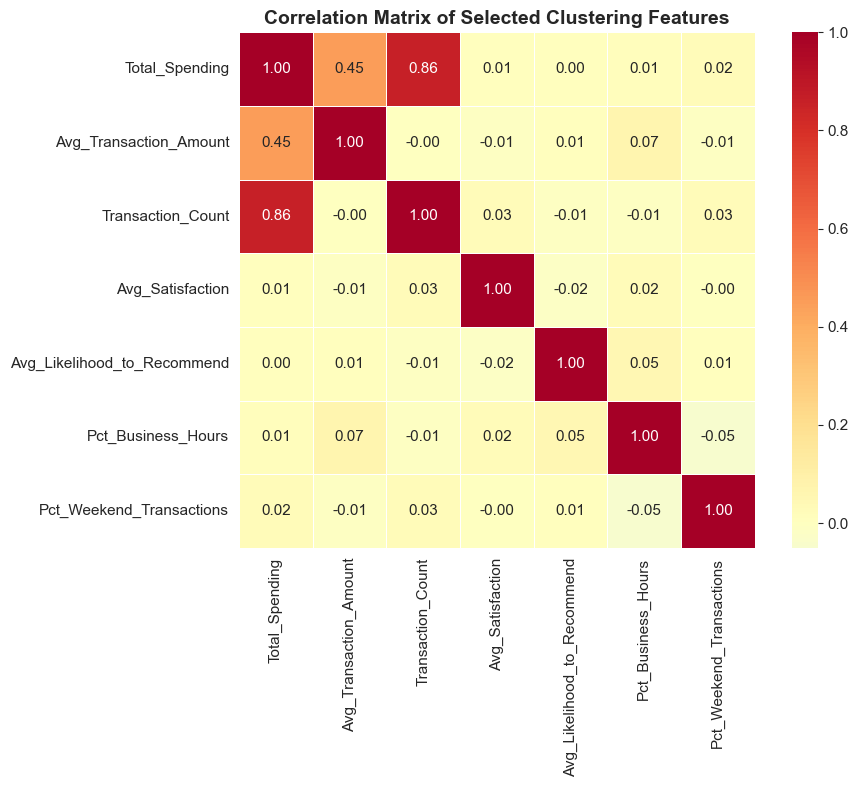


✓ Key Observations:
  • Total_Spending and Transaction_Count are correlated (expected)
  • Satisfaction and Likelihood_to_Recommend are correlated
  • Temporal features show independence from spending/satisfaction


In [17]:
# Feature correlation analysis
print("\nFeature Correlation Matrix:")
plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Selected Clustering Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Key Observations:")
print("  • Total_Spending and Transaction_Count are correlated (expected)")
print("  • Satisfaction and Likelihood_to_Recommend are correlated")
print("  • Temporal features show independence from spending/satisfaction")

---
## STEP 4: Data Preprocessing - Standardization

K-Means is sensitive to feature scales, so we standardize features to have zero mean and unit variance.

In [18]:
print("\nSTEP 4: DATA STANDARDIZATION")
print("*" * 80)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=available_features)

print("\nBefore Standardization:")
print(X.describe().round(2))

print("\nAfter Standardization:")
print(X_scaled_df.describe().round(2))

print("\n✓ Features standardized (mean=0, std=1)")


STEP 4: DATA STANDARDIZATION
********************************************************************************

Before Standardization:
       Total_Spending  Avg_Transaction_Amount  Transaction_Count  \
count          993.00                  993.00             993.00   
mean         12567.47                 2497.35               5.04   
std           6423.29                  758.13               2.19   
min            286.00                  286.00               1.00   
25%           7777.00                 2015.00               3.00   
50%          11939.00                 2457.88               5.00   
75%          16531.00                 2930.75               6.00   
max          37281.00                 4993.00              13.00   

       Avg_Satisfaction  Avg_Likelihood_to_Recommend  Pct_Business_Hours  \
count            993.00                       993.00              993.00   
mean               5.53                         5.46                0.33   
std                2.78

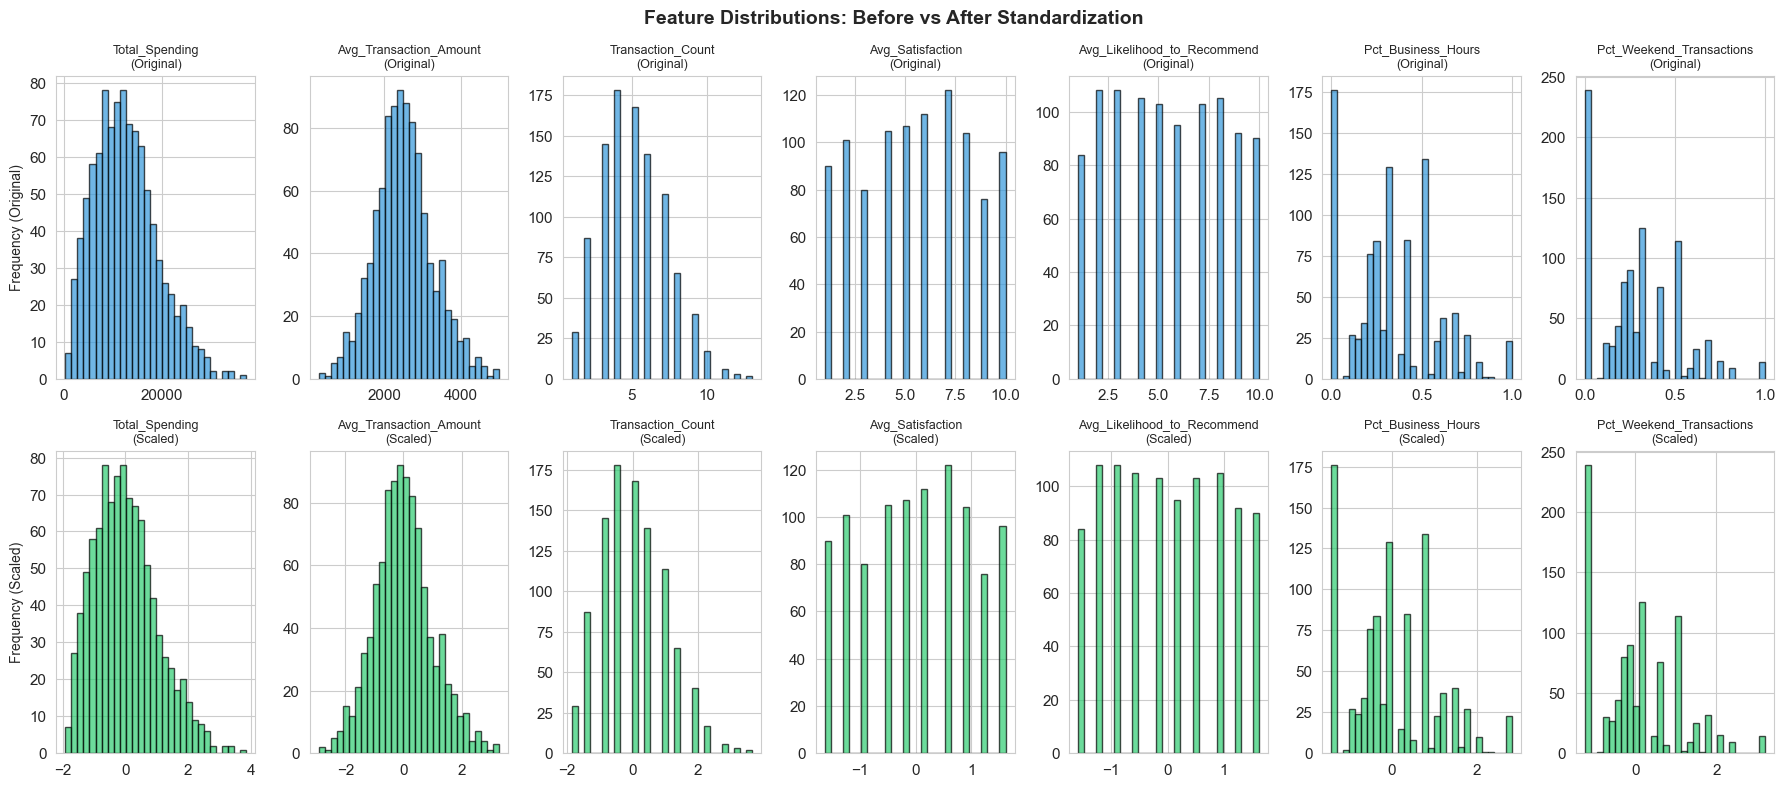

In [19]:
# Visualize feature distributions before/after scaling
fig, axes = plt.subplots(2, len(available_features), figsize=(18, 8))
fig.suptitle('Feature Distributions: Before vs After Standardization', fontsize=14, fontweight='bold')

for i, feat in enumerate(available_features):
    # Before scaling
    axes[0, i].hist(X[feat], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{feat}\n(Original)', fontsize=9)
    axes[0, i].set_xlabel('')
    
    # After scaling
    axes[1, i].hist(X_scaled_df[feat], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'{feat}\n(Scaled)', fontsize=9)
    axes[1, i].set_xlabel('')

axes[0, 0].set_ylabel('Frequency (Original)', fontsize=10)
axes[1, 0].set_ylabel('Frequency (Scaled)', fontsize=10)

plt.tight_layout()
plt.show()

---
## STEP 5: Finding Optimal Number of Clusters (k)

We use multiple methods to determine the optimal number of clusters:
1. **Elbow Method** - Plot inertia vs k, look for the "elbow"
2. **Silhouette Score** - Measures cluster cohesion and separation
3. **Davies-Bouldin Score** - Measures average similarity between clusters


STEP 5: FINDING OPTIMAL NUMBER OF CLUSTERS
********************************************************************************


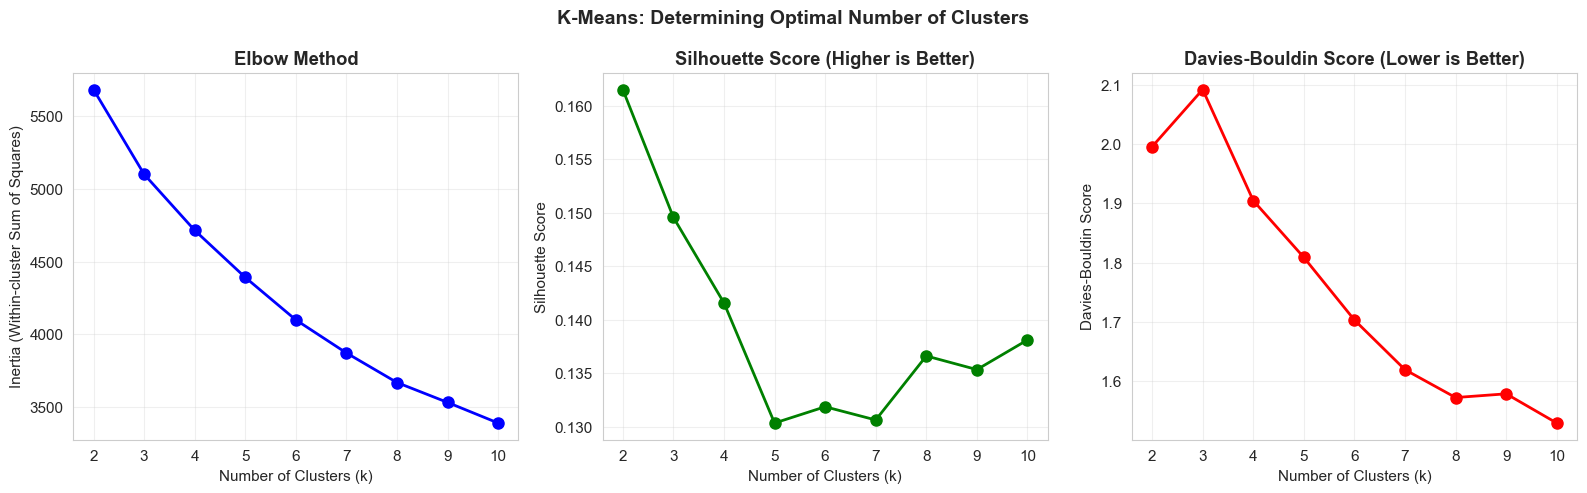


Cluster Evaluation Metrics:


,k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,5682.6274,0.1615,221.1930,1.9956
1,3,5100.4876,0.1496,179.5914,2.0921
2,4,4715.0170,0.1416,156.3365,1.9048
3,5,4391.5906,0.1303,143.9511,1.8089
4,6,4099.5384,0.1319,137.3029,1.7034
5,7,3872.2919,0.1306,130.6550,1.6196
6,8,3669.0688,0.1366,125.8670,1.5726
7,9,3532.3107,0.1353,119.0435,1.5789
8,10,3390.7014,0.1381,114.6853,1.5296



✓ Optimal k based on Silhouette Score: 2

Note: The elbow method suggests k=3 or k=4 as good choices.
      We will use k=4 for better business interpretability.


In [20]:
print("\nSTEP 5: FINDING OPTIMAL NUMBER OF CLUSTERS")
print("*" * 80)

# Test different values of k
k_range = range(2, 11)
inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    calinski_scores.append(calinski_harabasz_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

# Plot evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means: Determining Optimal Number of Clusters', fontsize=14, fontweight='bold')

# Elbow Method
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=11)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score (Higher is Better)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin Score
axes[2].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[2].set_title('Davies-Bouldin Score (Lower is Better)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print metrics table
print("\nCluster Evaluation Metrics:")
metrics_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_bouldin_scores
}).round(4)
display(metrics_df)

# Find optimal k based on silhouette score
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal k based on Silhouette Score: {optimal_k_silhouette}")
print(f"\nNote: The elbow method suggests k=3 or k=4 as good choices.")
print(f"      We will use k=4 for better business interpretability.")

---
## STEP 6: Apply K-Means Clustering

In [21]:
print("\nSTEP 6: APPLYING K-MEANS CLUSTERING")
print("*" * 80)

# Apply K-Means with chosen k
k_optimal = 4  # Chosen based on elbow method and business interpretability

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the dataset
customer_features['Cluster'] = kmeans_labels

print(f"\n✓ K-Means clustering completed with k={k_optimal}")
print(f"\nCluster Distribution:")
cluster_dist = customer_features['Cluster'].value_counts().sort_index()
for cluster, count in cluster_dist.items():
    print(f"  Cluster {cluster}: {count} customers ({count/len(customer_features)*100:.1f}%)")

# Evaluation metrics
print(f"\nClustering Evaluation Metrics:")
print(f"  • Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")
print(f"  • Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}")
print(f"  • Davies-Bouldin Score: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}")

print(f"\n✓ Metric Interpretation:")
print(f"  • Silhouette Score: Higher is better (range: -1 to 1)")
print(f"  • Calinski-Harabasz: Higher is better (no upper bound)")
print(f"  • Davies-Bouldin: Lower is better (≥0)")


STEP 6: APPLYING K-MEANS CLUSTERING
********************************************************************************

✓ K-Means clustering completed with k=4

Cluster Distribution:
  Cluster 0: 327 customers (32.9%)
  Cluster 1: 253 customers (25.5%)
  Cluster 2: 189 customers (19.0%)
  Cluster 3: 224 customers (22.6%)

Clustering Evaluation Metrics:
  • Silhouette Score: 0.1416
  • Calinski-Harabasz Score: 156.3365
  • Davies-Bouldin Score: 1.9048

✓ Metric Interpretation:
  • Silhouette Score: Higher is better (range: -1 to 1)
  • Calinski-Harabasz: Higher is better (no upper bound)
  • Davies-Bouldin: Lower is better (≥0)


---
## STEP 7: Cluster Visualization


STEP 7: CLUSTER VISUALIZATION
********************************************************************************

PCA Loadings (correlation of each feature with PC1 and PC2):
------------------------------------------------------------
                               PC1    PC2
Total_Spending               0.707 -0.008
Avg_Transaction_Amount       0.327  0.467
Transaction_Count            0.626 -0.245
Avg_Satisfaction             0.021  0.004
Avg_Likelihood_to_Recommend  0.003  0.350
Pct_Business_Hours           0.026  0.661
Pct_Weekend_Transactions     0.029 -0.404

PC1 INTERPRETATION:
  Variance explained: 28.1%
  Top contributors: Total_Spending, Transaction_Count, Avg_Transaction_Amount
  Loadings: {'Total_Spending': 0.7069471232616465, 'Transaction_Count': 0.6255394216367979, 'Avg_Transaction_Amount': 0.32706033839808324}

PC2 INTERPRETATION:
  Variance explained: 15.8%
  Top contributors: Pct_Business_Hours, Avg_Transaction_Amount, Pct_Weekend_Transactions
  Loadings: {'Pct_Busines

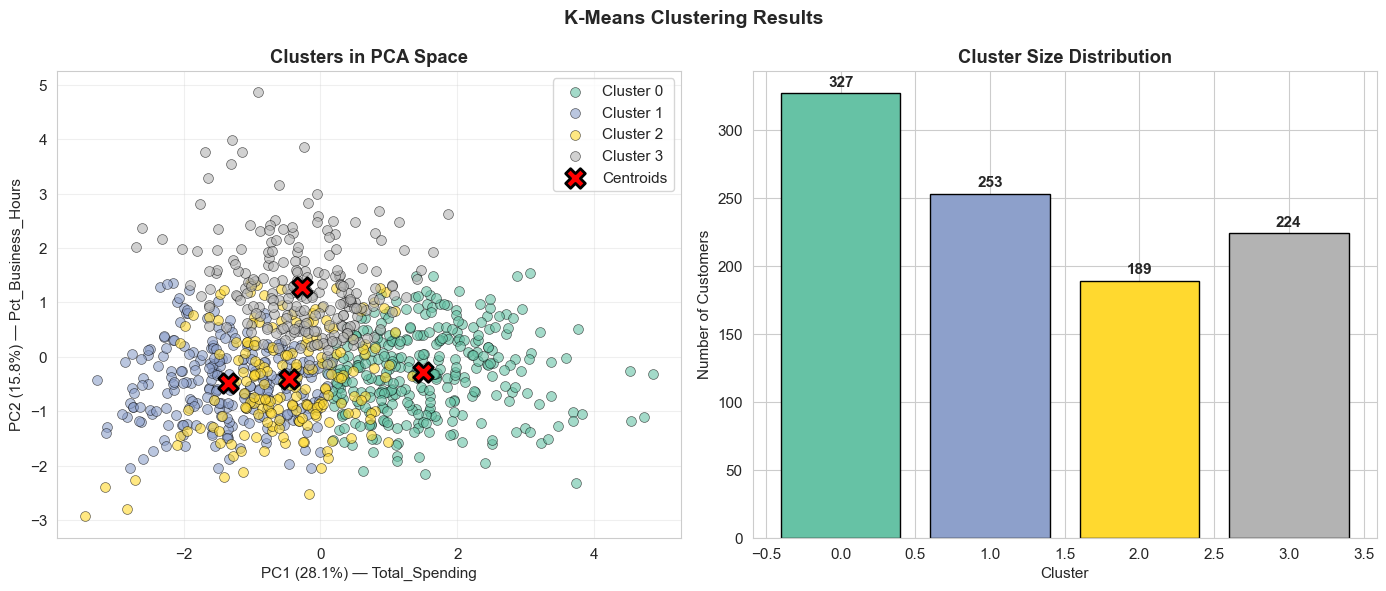


✓ PCA explains 44.0% of variance (PC1: 28.1% + PC2: 15.8%)


In [22]:
print("\nSTEP 7: CLUSTER VISUALIZATION")
print("*" * 80)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Extract and display PCA loadings ---
# Get feature names
feature_names = X.columns.tolist()

# Create loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_names
)

print("\nPCA Loadings (correlation of each feature with PC1 and PC2):")
print("-" * 60)
print(loadings.round(3))

# Identify top contributors for interpretation
print("\n" + "=" * 60)
print("PC1 INTERPRETATION:")
print(f"  Variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%")
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False)
print(f"  Top contributors: {', '.join(top_pc1.head(3).index.tolist())}")
print(f"  Loadings: {loadings.loc[top_pc1.head(3).index, 'PC1'].to_dict()}")

print("\nPC2 INTERPRETATION:")
print(f"  Variance explained: {pca.explained_variance_ratio_[1]*100:.1f}%")
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False)
print(f"  Top contributors: {', '.join(top_pc2.head(3).index.tolist())}")
print(f"  Loadings: {loadings.loc[top_pc2.head(3).index, 'PC2'].to_dict()}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Means Clustering Results', fontsize=14, fontweight='bold')

# PCA scatter plot
colors = plt.cm.Set2(np.linspace(0, 1, k_optimal))
for i in range(k_optimal):
    mask = kmeans_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[i]], label=f'Cluster {i}', 
                    alpha=0.6, edgecolors='black', linewidth=0.5, s=50)

# Plot centroids
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
                s=200, edgecolors='black', linewidth=2, label='Centroids')

# --- More descriptive axis labels ---
# Build interpretive labels based on top loading
pc1_top = top_pc1.index[0]
pc2_top = top_pc2.index[0]
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) — {pc1_top}')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%) — {pc2_top}')

axes[0].set_title('Clusters in PCA Space', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cluster size bar chart
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Cluster Size Distribution', fontweight='bold')
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of variance (PC1: {pca.explained_variance_ratio_[0]*100:.1f}% + PC2: {pca.explained_variance_ratio_[1]*100:.1f}%)")

---
## STEP 8: Cluster Profiling


STEP 8: CLUSTER PROFILING
********************************************************************************

Cluster Profiles (Mean Values):


,Total_Spending,Avg_Transaction_Amount,Transaction_Count,Avg_Satisfaction,Avg_Likelihood_to_Recommend,Pct_Business_Hours,Pct_Weekend_Transactions
Cluster,,,,,,,
0,19390.33,2644.76,7.42,5.82,5.29,0.31,0.27
1,6671.10,1800.72,3.71,5.55,5.01,0.23,0.20
2,10269.90,2640.56,3.98,4.95,5.80,0.29,0.58
3,11205.62,2948.17,3.95,5.57,5.91,0.53,0.13


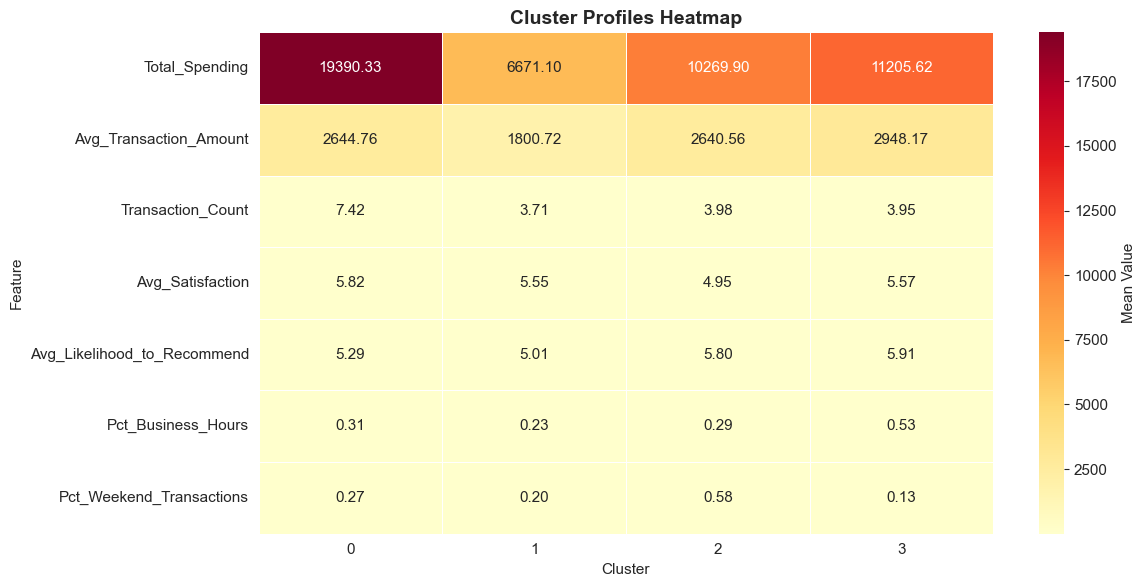

In [29]:
print("\nSTEP 8: CLUSTER PROFILING")
print("*" * 80)

# Calculate cluster means for each feature
cluster_profiles = customer_features.groupby('Cluster')[available_features].mean().round(2)
print("\nCluster Profiles (Mean Values):")
display(cluster_profiles)

# Visualize cluster profiles as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='YlOrRd', fmt='.2f', 
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title('Cluster Profiles Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [30]:
# Create detailed cluster summary
print("\nDetailed Cluster Summary:")
print("-" * 50)

cluster_summary = customer_features.groupby('Cluster').agg({
    'Total_Spending': ['mean', 'median', 'std'],
    'Avg_Transaction_Amount': 'mean',
    'Transaction_Count': 'mean',
    'Avg_Satisfaction': 'mean',
    'Avg_Likelihood_to_Recommend': 'mean',
    'Pct_Business_Hours': 'mean',
    'Pct_Weekend_Transactions': 'mean',
    'Customer_ID': 'count'
}).round(2)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.rename(columns={'Customer_ID_count': 'Customer_Count'})

display(cluster_summary)


Detailed Cluster Summary:
--------------------------------------------------


,Total_Spending_mean,Total_Spending_median,Total_Spending_std,Avg_Transaction_Amount_mean,Transaction_Count_mean,Avg_Satisfaction_mean,Avg_Likelihood_to_Recommend_mean,Pct_Business_Hours_mean,Pct_Weekend_Transactions_mean,Customer_Count
Cluster,,,,,,,,,,
0,19390.33,18406.0,4736.34,2644.76,7.42,5.82,5.29,0.31,0.27,327
1,6671.10,6466.0,3028.34,1800.72,3.71,5.55,5.01,0.23,0.20,253
2,10269.90,10287.0,3688.27,2640.56,3.98,4.95,5.80,0.29,0.58,189
3,11205.62,11367.5,3855.79,2948.17,3.95,5.57,5.91,0.53,0.13,224


---
## STEP 9: Business Interpretation & Insights

In [31]:
print("\nSTEP 9: BUSINESS INTERPRETATION & INSIGHTS")
print("*" * 80)

# Calculate overall averages for comparison
overall_avg = customer_features[available_features].mean()

# Generate business interpretations for each cluster
for cluster in sorted(customer_features['Cluster'].unique()):
    cluster_data = cluster_profiles.loc[cluster]
    cluster_size = (customer_features['Cluster'] == cluster).sum()
    cluster_pct = cluster_size / len(customer_features) * 100
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {cluster_size} customers ({cluster_pct:.1f}%)")
    print(f"{'='*60}")
    
    # Analyze characteristics
    spending_level = 'High' if cluster_data['Total_Spending'] > overall_avg['Total_Spending'] else 'Low'
    satisfaction_level = 'High' if cluster_data['Avg_Satisfaction'] > overall_avg['Avg_Satisfaction'] else 'Low'
    engagement_level = 'High' if cluster_data['Transaction_Count'] > overall_avg['Transaction_Count'] else 'Low'
    business_hours_level = 'High' if cluster_data['Pct_Business_Hours'] > overall_avg['Pct_Business_Hours'] else 'Low'
    weekend_level = 'High' if cluster_data['Pct_Weekend_Transactions'] > overall_avg['Pct_Weekend_Transactions'] else 'Low'
    
    print(f"\nKey Characteristics:")
    print(f"  • Total Spending: ₱{cluster_data['Total_Spending']:,.0f} ({spending_level} vs avg ₱{overall_avg['Total_Spending']:,.0f})")
    print(f"  • Avg Transaction: ₱{cluster_data['Avg_Transaction_Amount']:,.0f}")
    print(f"  • Transaction Count: {cluster_data['Transaction_Count']:.1f} ({engagement_level} vs avg {overall_avg['Transaction_Count']:.1f})")
    print(f"  • Satisfaction Score: {cluster_data['Avg_Satisfaction']:.1f}/10 ({satisfaction_level})")
    print(f"  • Likelihood to Recommend: {cluster_data['Avg_Likelihood_to_Recommend']:.1f}/10")
    print(f"  • Business Hours Activity: {cluster_data['Pct_Business_Hours']*100:.0f}% ({business_hours_level})")
    print(f"  • Weekend Activity: {cluster_data['Pct_Weekend_Transactions']*100:.0f}% ({weekend_level})")
    
    # Generate segment name and recommendation based on multiple dimensions
    if spending_level == 'High' and engagement_level == 'High':
        segment_name = "Premium High-Value Customers"
        recommendation = "Maintain relationship with exclusive offers, VIP programs, early access to new products"
    elif spending_level == 'High' and satisfaction_level == 'Low':
        segment_name = "High-Value At-Risk"
        recommendation = "Priority intervention needed - investigate pain points, offer personalized recovery incentives"
    elif spending_level == 'Low' and satisfaction_level == 'High' and business_hours_level == 'High':
        segment_name = "Business Professionals"
        recommendation = "Target with B2B offerings, professional services, weekday promotions, and corporate packages"
    elif spending_level == 'Low' and weekend_level == 'High':
        segment_name = "Weekend Casual Users"
        recommendation = "Engage with weekend promotions, leisure-focused offerings, and family/lifestyle products"
    elif spending_level == 'Low' and satisfaction_level == 'High':
        segment_name = "Growth Potential"
        recommendation = "Cross-sell and upsell opportunities - they're satisfied but spending less; nurture with targeted campaigns"
    elif spending_level == 'Low' and satisfaction_level == 'Low':
        segment_name = "Needs Attention"
        recommendation = "Improve experience to increase satisfaction and spending; target with value propositions and feedback surveys"
    else:
        segment_name = "Standard Customers"
        recommendation = "Monitor engagement patterns and personalize based on transaction timing preferences"
    
    print(f"\n  → Segment Name: {segment_name}")
    print(f"  → Recommendation: {recommendation}")


STEP 9: BUSINESS INTERPRETATION & INSIGHTS
********************************************************************************

CLUSTER 0: 327 customers (32.9%)

Key Characteristics:
  • Total Spending: ₱19,390 (High vs avg ₱12,567)
  • Avg Transaction: ₱2,645
  • Transaction Count: 7.4 (High vs avg 5.0)
  • Satisfaction Score: 5.8/10 (High)
  • Likelihood to Recommend: 5.3/10
  • Business Hours Activity: 31% (Low)
  • Weekend Activity: 27% (Low)

  → Segment Name: Premium High-Value Customers
  → Recommendation: Maintain relationship with exclusive offers, VIP programs, early access to new products

CLUSTER 1: 253 customers (25.5%)

Key Characteristics:
  • Total Spending: ₱6,671 (Low vs avg ₱12,567)
  • Avg Transaction: ₱1,801
  • Transaction Count: 3.7 (Low vs avg 5.0)
  • Satisfaction Score: 5.5/10 (High)
  • Likelihood to Recommend: 5.0/10
  • Business Hours Activity: 23% (Low)
  • Weekend Activity: 20% (Low)

  → Segment Name: Growth Potential
  → Recommendation: Cross-sell and ups


Cluster Comparison Radar Chart:
--------------------------------------------------


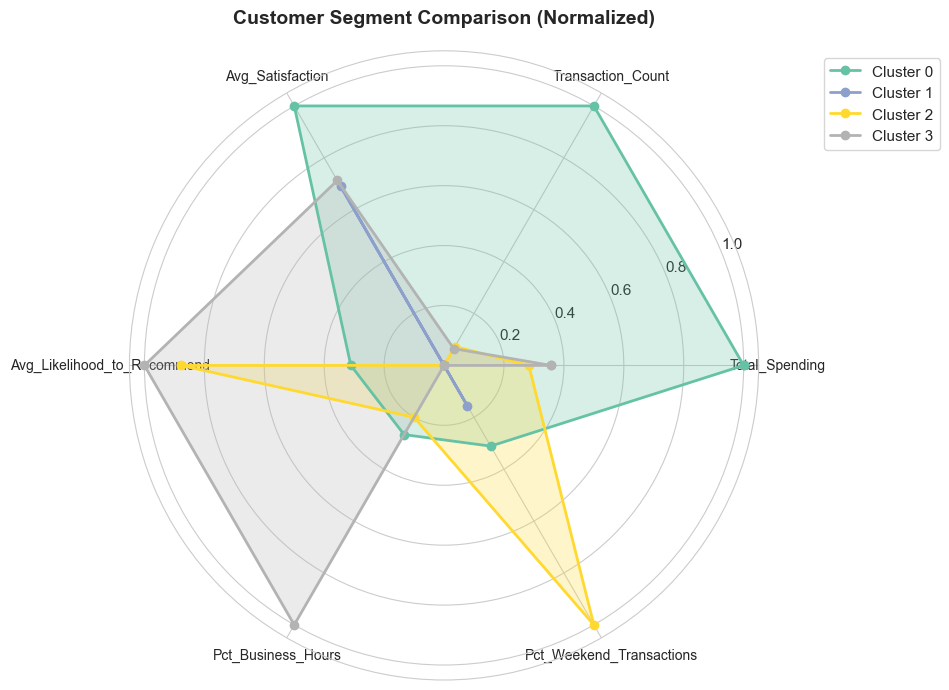

In [32]:
# Create radar chart for cluster comparison
print("\nCluster Comparison Radar Chart:")
print("-" * 50)

# Normalize profiles for radar chart
profiles_normalized = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

# Select key features for radar
radar_features = ['Total_Spending', 'Transaction_Count', 'Avg_Satisfaction', 
                  'Avg_Likelihood_to_Recommend', 'Pct_Business_Hours', 'Pct_Weekend_Transactions']

# Number of variables
N = len(radar_features)

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the loop

# Initialize the radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Colors for each cluster
colors = plt.cm.Set2(np.linspace(0, 1, len(cluster_profiles)))

for i, (cluster, row) in enumerate(profiles_normalized.iterrows()):
    values = row[radar_features].tolist()
    values += values[:1]  # Complete the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

# Set labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title('Customer Segment Comparison (Normalized)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()


Feature Distributions by Cluster:
--------------------------------------------------


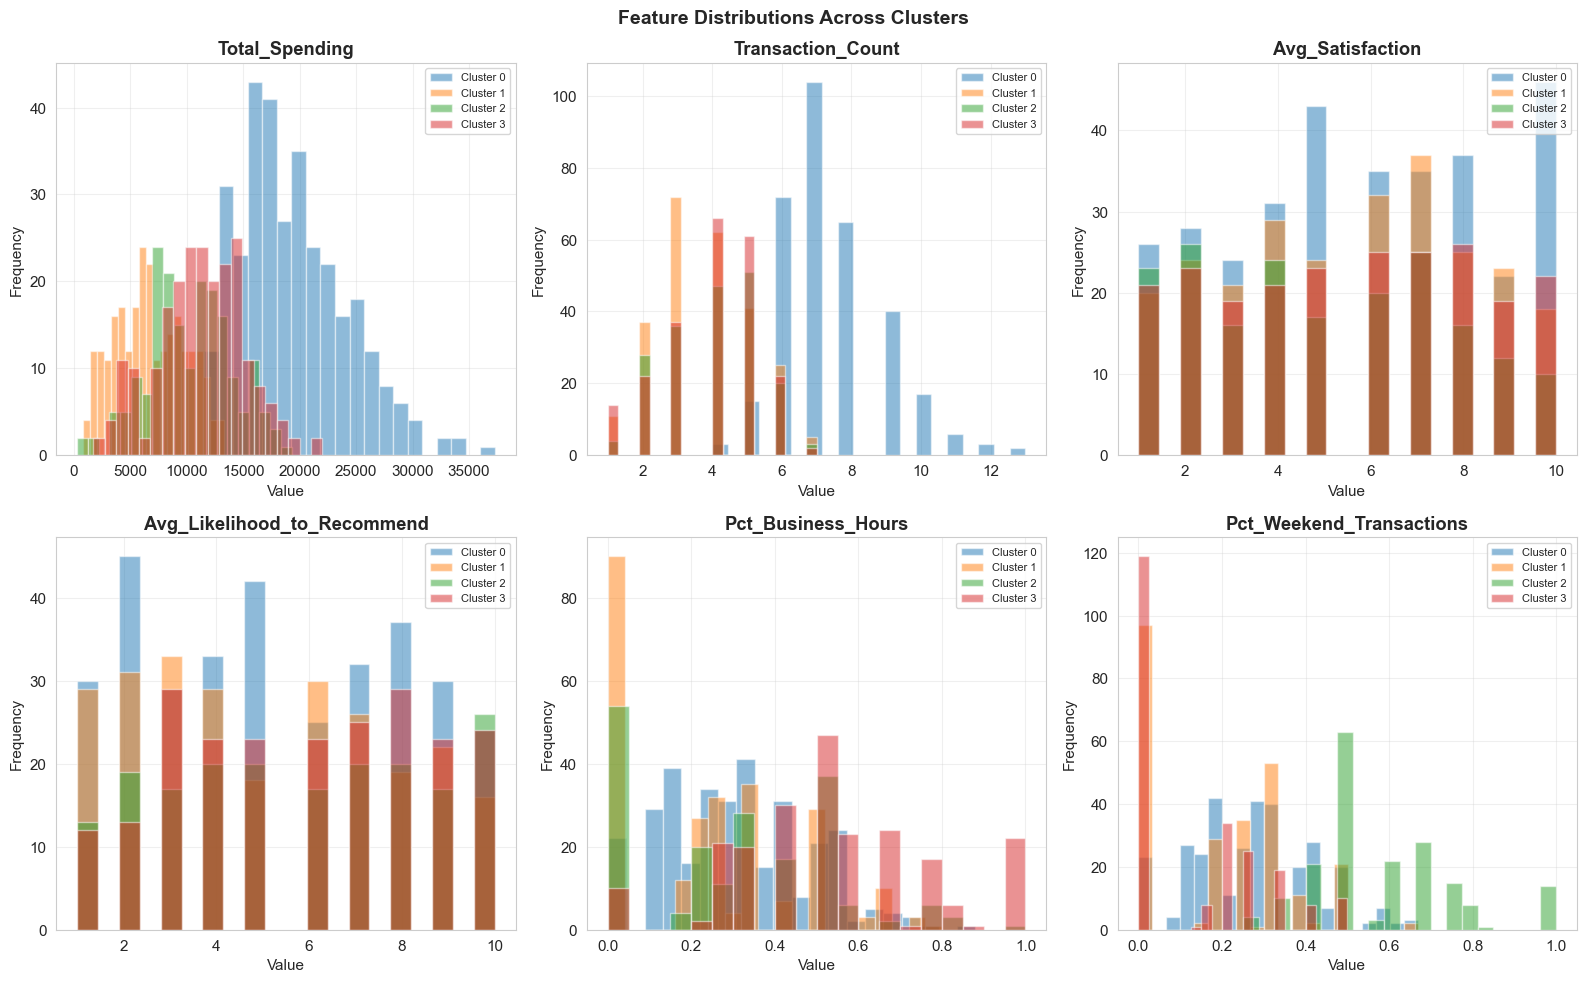

In [19]:
# Feature distribution by cluster
print("\nFeature Distributions by Cluster:")
print("-" * 50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions Across Clusters', fontsize=14, fontweight='bold')

plot_features = ['Total_Spending', 'Transaction_Count', 'Avg_Satisfaction', 
                 'Avg_Likelihood_to_Recommend', 'Pct_Business_Hours', 'Pct_Weekend_Transactions']

for idx, feat in enumerate(plot_features):
    row = idx // 3
    col = idx % 3
    
    for cluster in sorted(customer_features['Cluster'].unique()):
        cluster_data = customer_features[customer_features['Cluster'] == cluster][feat]
        axes[row, col].hist(cluster_data, bins=20, alpha=0.5, label=f'Cluster {cluster}')
    
    axes[row, col].set_title(feat, fontweight='bold')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend(loc='upper right', fontsize=8)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## STEP 10: Export Results

In [20]:
print("\nSTEP 10: EXPORT CLUSTERING RESULTS")
print("*" * 80)

# Export customer data with cluster assignments
export_cols = ['Customer_ID'] + available_features + ['Cluster']
export_df = customer_features[export_cols].copy()

# Export to CSV
export_df.to_csv('FinMark_Customer_Clusters.csv', index=False)

print(f"\n✓ Exported: FinMark_Customer_Clusters.csv")
print(f"  • Rows: {len(export_df):,} customers")
print(f"  • Columns: {len(export_df.columns)}")
print(f"  • Contains: Customer features + cluster assignments")

# Export cluster profiles
cluster_profiles.to_csv('FinMark_Cluster_Profiles.csv')
print(f"\n✓ Exported: FinMark_Cluster_Profiles.csv")
print(f"  • Contains: Mean feature values for each cluster")


STEP 10: EXPORT CLUSTERING RESULTS
********************************************************************************

✓ Exported: FinMark_Customer_Clusters.csv
  • Rows: 993 customers
  • Columns: 9
  • Contains: Customer features + cluster assignments

✓ Exported: FinMark_Cluster_Profiles.csv
  • Contains: Mean feature values for each cluster


In [21]:
print("\n" + "*" * 80)
print("MILESTONE 2 - CLUSTERING COMPLETION SUMMARY")
print("*" * 80)

print(f"""
✓ ALGORITHM SELECTION:
  • Selected: K-Means Clustering
  • Rationale: Best suited for FinMark's numerical customer data,
    provides interpretable centroids, scalable, and reproducible

✓ DATA PREPARATION:
  • Loaded {len(customer_features):,} customers from Milestone 1
  • Selected {len(available_features)} features for clustering
  • Standardized features for algorithm compatibility

✓ OPTIMAL CLUSTERS:
  • Method: Elbow method + Silhouette analysis
  • Chosen k: {k_optimal} clusters
  • Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}

✓ CLUSTER DISTRIBUTION:""")

for cluster, count in cluster_dist.items():
    print(f"  • Cluster {cluster}: {count} customers ({count/len(customer_features)*100:.1f}%)")

print(f"""
✓ DELIVERABLES EXPORTED:
  • FinMark_Customer_Clusters.csv (customer-level cluster assignments)
  • FinMark_Cluster_Profiles.csv (cluster characteristics)

""")
print("*" * 80)
print("READY FOR PRESENTATION AND FINAL SUBMISSION!")
print("*" * 80)


********************************************************************************
MILESTONE 2 - CLUSTERING COMPLETION SUMMARY
********************************************************************************

✓ ALGORITHM SELECTION:
  • Selected: K-Means Clustering
  • Rationale: Best suited for FinMark's numerical customer data,
    provides interpretable centroids, scalable, and reproducible

✓ DATA PREPARATION:
  • Loaded 993 customers from Milestone 1
  • Selected 7 features for clustering
  • Standardized features for algorithm compatibility

✓ OPTIMAL CLUSTERS:
  • Method: Elbow method + Silhouette analysis
  • Chosen k: 4 clusters
  • Silhouette Score: 0.1416

✓ CLUSTER DISTRIBUTION:
  • Cluster 0: 327 customers (32.9%)
  • Cluster 1: 253 customers (25.5%)
  • Cluster 2: 189 customers (19.0%)
  • Cluster 3: 224 customers (22.6%)

✓ DELIVERABLES EXPORTED:
  • FinMark_Customer_Clusters.csv (customer-level cluster assignments)
  • FinMark_Cluster_Profiles.csv (cluster characteristics